In [1]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.3 MB/s eta 0:00:00


In [2]:
import zipfile
import os

zip_file = "Solar Radiation.zip"
extract_folder = "solar radiation"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted:")
print(os.listdir(extract_folder))

Files extracted:
['DSWRF-sfc_2020050209_ncum_imdaa_reanl_2df_09.nc', 'DSWRF-sfc_2020050109_ncum_imdaa_reanl_2df_09.nc', 'DSWRF-sfc_2020050213_ncum_imdaa_reanl_2df_13.nc', 'DSWRF-sfc_2020050122_ncum_imdaa_reanl_2df_22.nc', 'DSWRF-sfc_2020050113_ncum_imdaa_reanl_2df_13.nc', 'DSWRF-sfc_2020050222_ncum_imdaa_reanl_2df_22.nc']


In [3]:
import xarray as xr

In [8]:
ds = xr.open_dataset("solar radiation/DSWRF-sfc_2020050209_ncum_imdaa_reanl_2df_09.nc")

In [9]:
ds

<xarray.Dataset> Size: 752B
Dimensions:   (time: 1, lat: 8, lon: 17)
Coordinates:
  * time      (time) datetime64[ns] 8B 2020-05-02T10:00:00
  * lat       (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon       (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Data variables:
    msdwswrf  (time, lat, lon) float32 544B ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Jul 06 11:04:48 2026: cdo -f nc4c -z zip_4 sellonlatbox...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [10]:
ds["msdwswrf"]

<xarray.DataArray 'msdwswrf' (time: 1, lat: 8, lon: 17)> Size: 544B
[136 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-02T10:00:00
  * lat      (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon      (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Attributes:
    long_name:  Mean surface downward short-wave radiation flux
    units:      W m**-2
    param:      7.4.0

In [11]:
print(ds["msdwswrf"].values)

[[[539.9049 676.4049 737.4049 702.9049 650.4049 648.4049 555.4049
   700.4049 744.4049 738.4049 752.9049 750.9049 748.4049 746.4049
   744.4049 741.9049 739.4049]
  [682.9049 708.4049 659.4049 490.4049 445.4049 694.4049 677.4049
   744.4049 712.9049 644.4049 734.9049 747.9049 746.9049 745.4049
   742.9049 740.9049 738.9049]
  [739.9049 671.4049 654.9049 721.4049 628.9049 615.4049 722.9049
   748.4049 732.4049 701.4049 705.4049 734.9049 745.4049 743.9049
   741.4049 739.9049 738.4049]
  [727.9049 687.9049 676.9049 749.4049 755.4049 748.4049 722.4049
   706.9049 700.9049 696.9049 706.9049 718.4049 744.4049 741.4049
   734.9049 738.9049 737.4049]
  [643.4049 702.9049 736.4049 712.4049 710.4049 715.9049 691.4049
   677.9049 684.9049 662.4049 697.4049 723.9049 742.9049 737.4049
   721.9049 737.9049 736.4049]
  [625.4049 743.9049 757.9049 737.4049 692.4049 674.9049 665.9049
   655.9049 692.9049 667.9049 711.4049 737.9049 741.4049 738.4049
   730.9049 736.9049 734.4049]
  [742.9049 762.9049 7

In [12]:
solar = ds["msdwswrf"]

print("Minimum:", float(solar.min()))
print("Maximum:", float(solar.max()))
print("Mean:", float(solar.mean()))

Minimum: 445.4049072265625
Maximum: 771.4049072265625
Mean: 709.5049438476562


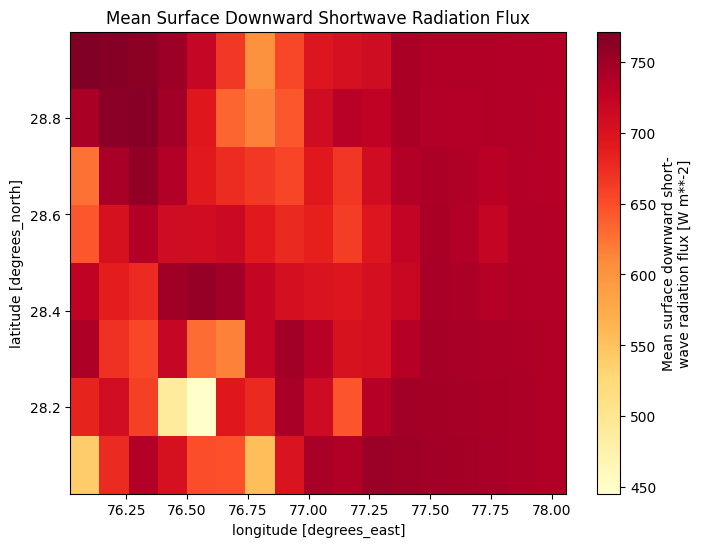

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

solar.plot(cmap="YlOrRd")

plt.title("Mean Surface Downward Shortwave Radiation Flux")
plt.show()

In [14]:
solar_point = solar.sel(lat=28.32, lon=77.04, method="nearest")
print(solar_point)

<xarray.DataArray 'msdwswrf' (time: 1)> Size: 4B
array([732.4049], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-02T10:00:00
    lon      float64 8B 77.04
    lat      float64 8B 28.32
Attributes:
    long_name:  Mean surface downward short-wave radiation flux
    units:      W m**-2
    param:      7.4.0
